Cleaned up notebook that focuses on the important bits of my dwarf-spheroidal galaxy pipeline. Currently tuned in to the Sextans galaxy. Will make a tweaked version that's more generic. 

#### Part 1: Housekeeping
- Imports
- Define functions
#### Part 2: Get field data
- Input field, make plots of proper motion & RVs
- Make cuts to data based on PM & RV, plus cut on log G (log g<3 for giants)
#### Summary plots of remaining stars
- Plot stars on their own, use galaxy data to make CMD.
- Aside: ASPCAP vs RV values
- V-error plots.
- Make fake stars

Once members are identified, we then move to Joker fitting. Do this on Tempest

- Derive and add things to data tables
- Do likelihood calculations, false-positive rejection. 
- Galaxy-level Semi-amplitude plots (remake the surface one with just "good"stars)
- E vs P plot?

#### Data outputs
- Make large scale plots of different things.
-  semi-amplitude plots?
- Make website pages for things.
#### Misc things
- Star spectra plotter

# Part 1: Housekeeping 
Library imports and custom functions. 

In [1]:
from astropy.io import fits  #Import libraries
from astropy.table import unique, Table
import astropy.table as tab
from astropy.io import ascii
from astropy.io.fits import writeto
from astropy.time import Time

import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import pathlib
import astropy.units as u
import astropy.constants as c
import thejoker as tj
import twobody as tb
import scipy as sp
from sklearn import datasets, linear_model

import sklearn
from sklearn.cluster import DBSCAN
sklearn.set_config(enable_metadata_routing=True)

import string
import os
import copy as cp
from dlnpyutils.utils import *
from dlnpyutils import coords
from matplotlib.offsetbox import AnchoredText
import seaborn as sb

        Use @ instead. [dlnpyutils.coords]


In [2]:
all_star = Table.read('allStar-dr17-synspec_rev1.fits') #Star-level summary table
all_visits = Table.read('allVisit-dr17-synspec_rev1.fits') #Visit-level summary table

In [3]:
def get_data(sID):
    """
    Given a star's APOGEE ID, collect its RV data into a Joker RV data object. 
    """
    visits = all_visits[all_visits['APOGEE_ID']==sID] #Visits with failed/bad RVs will be masked.
    mask = np.invert(visits["VHELIO"].mask) #Invert the mask, then use it to remove masked entries.
    
    col1 = visits["JD"][mask]
    col2 = visits["VHELIO"][mask]
    col3 = visits["VRELERR"][mask]
    
    col2.unit = u.km/u.s #Make sure the units are correct.
    col3.unit = u.km/u.s
    
    data = tj.RVData(t=col1, rv = col2, rv_err = col3)
    
    return data

In [4]:
def line_model(pars, x): #simple linear model
    """
    Evaluate a straight line model at the input x values.
    Assums y=mx + b format, with pars[0] = b, pars[1] = a
    """
    return pars[0] + pars[1]* np.array(x)

In [5]:
def plt_lin_fit (a,b,data): #plot a simple line
    x1 = np.min(data.t.value)
    x2 = np.max(data.t.value)

    y1 = a + x1*b
    y2 = a + x2*b

    plt.axline((x1,y1),(x2,y2))

In [6]:
def lin_fit (data):  #fit a line to data using line_model
    x = (data.t.value)-data.t_ref.value
    y = data.rv.value
    y_err = data.rv_err.value
    X = np.vander(x, N=2, increasing=True)

    Cov = np.diag(y_err**2)
    Cinv = np.linalg.inv(Cov)

    # using the new Python matrix operator
    best_pars_linalg = np.linalg.inv(X.T @ Cinv @ X) @ (X.T @ Cinv @ y)

    # we can also get the parameter covariance matrix
    #pars_Cov = np.linalg.inv(X.T @ Cinv @ X)

    return (x,y,y_err,best_pars_linalg)

In [7]:
def ln_likelihood(x,y,y_err, pars): #Calculate log likelihood of a linear model
    N = len(y)
    dy = y - line_model(pars, x)
    ivar = 1 / y_err**2  # inverse-variance
    return -0.5 * (
        N * np.log(2 * np.pi)
        + np.sum(2 * np.log(y_err))
        + np.sum(dy**2 * ivar)
    )

In [8]:
def mass2(p,k,e,mstar=1.0): #Calculate the mass of a binary companion
    """
    Calculate secondary mass for Keplerian orbit
    p - period (If units not given, assumed to be in days.)
    k - semi-amplitude (If units not given, assumed to be in km/s.)
    e - eccentricity 
    mstar - primary star mass (if units not given, assumed to be in solar masses. Default 1Msol)
    """
    
    if not('time' in u.get_physical_type(p)):
        p = p *u.day
    if not('speed' in u.get_physical_type(k)):
        k = k *(u.km/u.s)
    if not ('mass' in u.get_physical_type(mstar)):
        mstar = m *u.solMass

    k = np.abs(k)
    G = c.G
    mass_fn = (p * k**3)*(1-e**2)**(3/2) / (2*np.pi*G)

    M_one = (mass_fn*(mstar)**2)**(1./3.)
    M_two = (mass_fn*(mstar+M_one)**2)**(1./3.)
    m_sini = (mass_fn*(mstar+M_two)**2)**(1./3.)

    #print(msini)
    return m_sini.to(u.solMass)

In [9]:
def period_at_surface(M1, logg, e=0, M2=0):  #calculate the approximate orbital period at the surface of a star
    G = c.G
    #If input masses have no mass units, assume it is given in solar masses.
    if not('mass' in u.get_physical_type(M1)):
        M1 = M1 *u.Msun
    if not('mass' in u.get_physical_type(M2)):
        M2 = M2 *u.Msun
    
    R1 = np.sqrt(G*M1 / (10**logg * u.cm/u.s**2))
    a = R1/(1-e)
    P = 2*np.pi * (a**(3/2))/np.sqrt(G*(M1+M2)) 
    return P.to(u.day)

In [10]:
def v_err_adj_1(v_err): #Crude v_err adjustment
    if ('velocity' in u.get_physical_type(v_err)):
        v_err = (v_err.to(u.km/u.s)).value

    offset = np.sqrt(((3.5*v_err)**1.2)**2 + 0.072**2)
    return offset

In [11]:
def v_err_adj_2(v_err): #More sophisticated v_err adjustment
    if ('velocity' in u.get_physical_type(v_err)):
        v_err = (v_err.to(u.km/u.s)).value
    
    m = 1.13893 #Averages for multiple runs of RANSAC
    b = 0.424407

    v_err_adjusted = 10**(m*np.log10(v_err)+b)
    return v_err_adjusted *(u.km/u.s)

# Part 2: Galaxy Level Info

Now we need to identify our target in the APOGEE files, and isolate the member stars. First, find the field (or fields, you might have to tweak that if it's spread over multiple) in the list of APOGEE targets. Then, look up the most recent mean RV and proper motion values for the galaxy as can be found in the literature. Enter those values below. 

In [12]:
#Un-comment to print out all fields in DR17
#with np.printoptions(threshold=np.inf):
#    print(np.unique(all_star["FIELD"].data))

In [13]:
field = 'SEXTANS' #Field name
rv = 224.3       #Average radial velocity of the target (km/s)
pm_ra = -0.409   #Proper motion of the target
pm_dec = -0.047  ##mas/year

In [14]:
im_folder = "images/"+field

if not os.path.exists(im_folder):
    os.makedirs(im_folder)

In [15]:
apo_gal = all_star[all_star["FIELD"]==field]
len(apo_gal)

265

Now, let's look at what we have. How often were these stars visited, and what range of sizes (gravities) do they tend to have? Most targets outside of the Milky Way should be red giants with log g <3, anything higher will probably be a field star. 

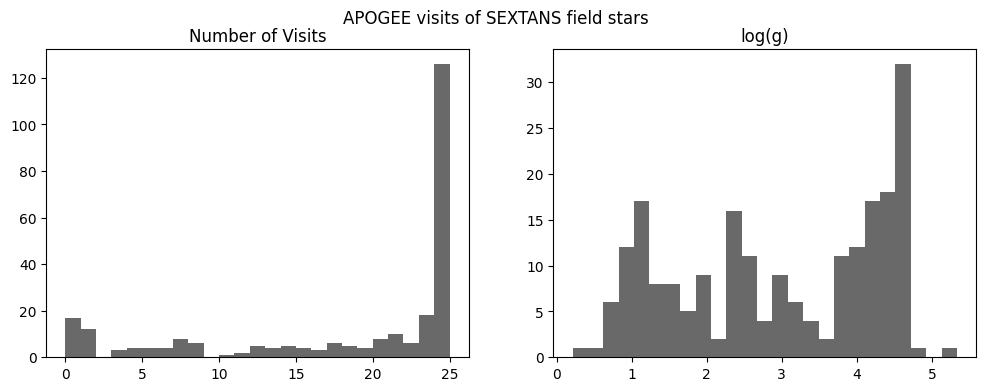

In [16]:
fig, (ax1,ax2) = plt.subplots(1, 2)

fig.set_size_inches([12,4])
fig.suptitle("APOGEE visits of " +field+" field stars")

ax1.set_title("Number of Visits")
ax1.hist(apo_gal["NVISITS"],bins=25,color='dimgray');

ax2.set_title("log(g)")
ax2.hist(apo_gal["LOGG"],bins=25,color='dimgray');

plt.savefig(im_folder + "/sextans_field_visits.png",dpi=150,bbox_inches='tight') 

## Plots to look at field kinematics

For a dwarf-spheroidal galaxy, the kinematic clustering should be pretty tight and readily visible in both RV and proper motion:

Text(0, 0.5, '')

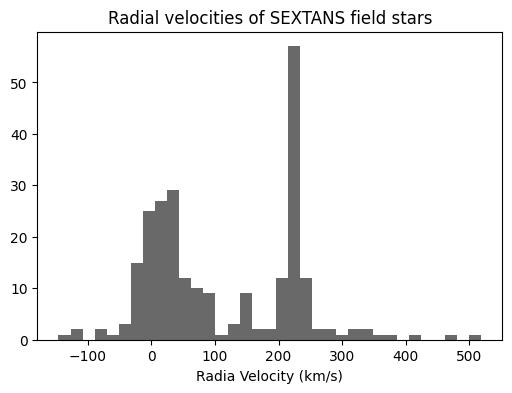

In [17]:
plt.figure(figsize=(6,4))
counts6, bins3,patches=plt.hist(apo_gal["VHELIO_AVG"],bins=35,color='dimgray')

plt.title("Radial velocities of "+ field+" field stars")
plt.xlabel("Radia Velocity (km/s)")
plt.ylabel("")

Text(0.5, 1.0, 'Gaia Proper motion for SEXTANS observations')

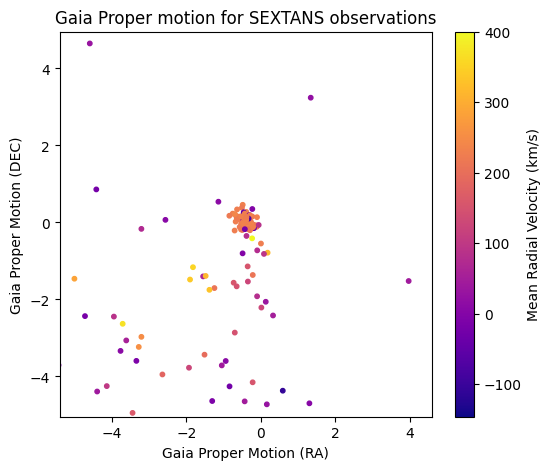

In [18]:
ra_min = pm_ra-5  #mas/year
ra_max = pm_ra+5
dec_min = pm_dec-5
dec_max = pm_dec+5

pm_fig = plt.figure(figsize=(6,5))
plt.scatter(apo_gal["GAIAEDR3_PMRA"],apo_gal["GAIAEDR3_PMDEC"],c=apo_gal["VHELIO_AVG"],s=10,cmap="plasma",vmax = 400)
plt.xlim([ra_min,ra_max])
plt.ylim([dec_min,dec_max])
plt.colorbar(label='Mean Radial Velocity (km/s)')

plt.xlabel('Gaia Proper Motion (RA)')
plt.ylabel('Gaia Proper Motion (DEC)')
plt.title('Gaia Proper motion for '+ field+" observations")

#plt.savefig("sextans_field_pms.png",dpi=200)

## Make cuts in RV & PM (& log G) to isolate galaxy members

Now we can start isolating the stars using the kinematics. For Sextans, I got the rv scatter from literature, if that's not available, just estimate something from the RV graph and divide by 3. For proper motion, I kinda eye-balled it as well. 

In [19]:
rv_scatter = 7.9  #Spread of the target's radial velocity (default is to select stars within 3x this range)
pm_radius = 0.5   #Radius in the proper motion plane (uses simple distance from center)


In [20]:
rv_min = rv - (3*rv_scatter)
rv_max = rv + (3*rv_scatter)

vcut_mask = (apo_gal["VHELIO_AVG"]>rv_min)&(apo_gal["VHELIO_AVG"]<rv_max)

In [21]:
pm_delta = np.sqrt( (apo_gal["GAIAEDR3_PMRA"]-pm_ra)**2 + (apo_gal["GAIAEDR3_PMDEC"]-pm_dec)**2)
pm_mask = pm_delta < pm_radius
pm_mask = pm_mask.data

Also, as mentioned above, giant stars have log(g) < 3, so anything with a higher log(g) will likely be a field star.

In [22]:
logg_mask = (apo_gal["LOGG"]<3)| (apo_gal["LOGG"]<3).mask

In [23]:
apo_vpm = apo_gal[vcut_mask & pm_mask]
apo_vpmg = apo_gal[vcut_mask & pm_mask & logg_mask]

In [24]:
apo_vpm.sort("LOGG")
apo_vpmg.sort("LOGG")
print(len(apo_vpmg)) 

66


### Re-make RV/PM plots with selection overlain

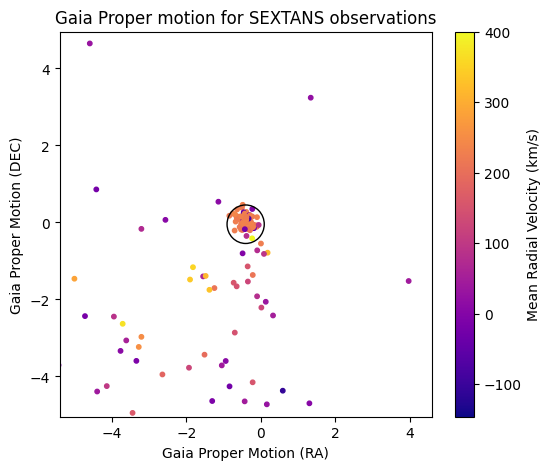

In [25]:
pm_circ = plt.Circle((pm_ra,pm_dec),pm_radius,color='black',fill=False)
ax = pm_fig.gca()
ax.add_patch(pm_circ)

pm_fig.savefig(im_folder + "/sextans_field_pms.png",dpi=200,bbox_inches='tight')
pm_fig

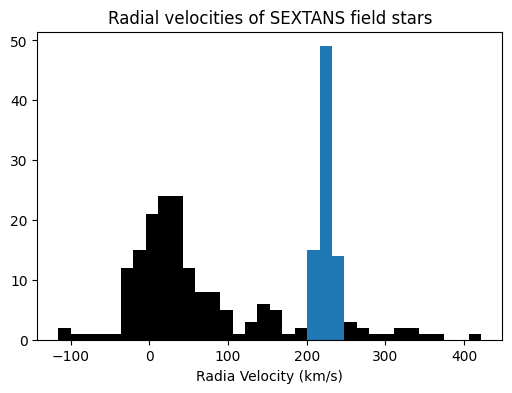

In [26]:
nbins = 35
binz = np.zeros(nbins)

place = 20
width = 3
bin_delta = (rv_max-rv_min)/width

for i in range(nbins):
    binz[i] = rv_min - (place-i)*bin_delta

binz

apo_v = apo_gal[vcut_mask]

plt.figure(figsize=(6,4))
counts6, bins3,patches=plt.hist(apo_gal["VHELIO_AVG"],bins=binz,color='black')
plt.hist(apo_v["VHELIO_AVG"],bins=binz,color='tab:blue')

plt.title("Radial velocities of "+ field+" field stars")
plt.xlabel("Radia Velocity (km/s)")
plt.ylabel("")

plt.savefig(im_folder + "/sextans_field_rvs.png",dpi=200,bbox_inches='tight')

## Summary Plots of members

This first cell is an attempt to figure out hwo many visits for different stars were actually successful. Might fiddle with this more.

In [27]:
nominal_visits = np.empty(0)

for star in apo_vpmg:
    sID = star["APOGEE_ID"]
    data = get_data(sID)
    n_visits = len(data)
    nominal_visits = np.append(nominal_visits,n_visits)

nominal_visits

array([25., 24., 23., 24., 24., 24., 24., 24., 24., 24., 23., 23., 20.,
       16., 24., 22., 23., 24., 21., 21., 23., 10., 24., 24., 22., 14.,
       15., 24., 22., 14., 22., 24., 14., 22., 24., 23., 16., 23., 17.,
        7., 24., 23., 22., 18., 23.,  9., 15., 24., 13., 12., 21., 18.,
       11., 22., 17., 23., 22., 13.,  9., 14., 11., 23., 17., 24., 23.,
        8.])

### Some stats on the APOGEE visits

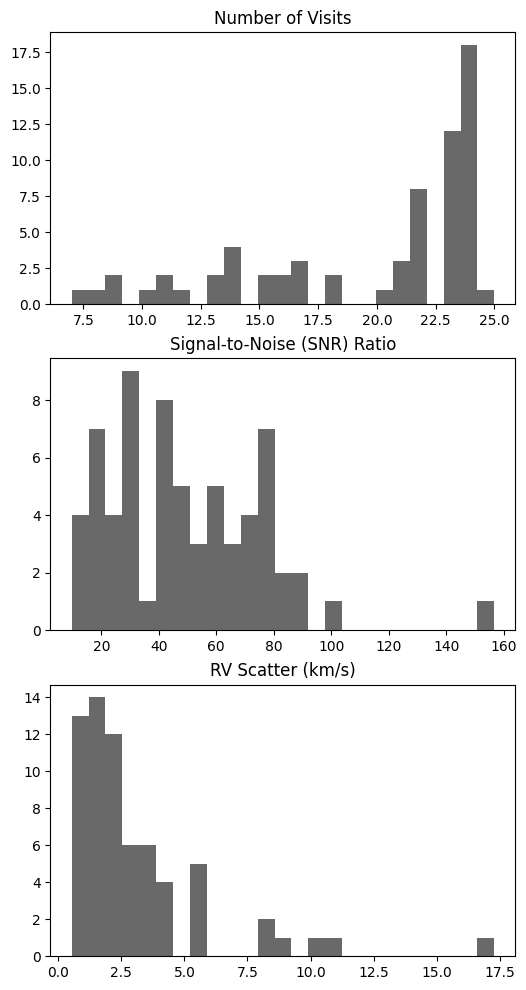

In [28]:
fig, ((ax1,ax2,ax3)) = plt.subplots(3, 1)
fig.set_size_inches([6,12])
#fig.suptitle("Summary of APOGEE Visits of "+ field+" Members")

ax1.set_title("Number of Visits")
ax1.hist(nominal_visits,bins=25,color='dimgray',label = "All-Visit visits") #tweak axes ranges to not be fractional

#n,bins,patches =ax1.hist(apo_vpm["NVISITS"],bins=25,color='dimgray',label="All-Star visits")
#ax1.hist(nominal_visits,bins=bins,color='tab:blue',hatch='//',alpha=0.4,label = "All-Visit visits")
#ax1.legend()
#ax1.set_xlabel("visits")
#ax1.set_ylabel("# of stars")

ax2.set_title("Signal-to-Noise (SNR) Ratio")
ax2.hist(apo_vpmg["SNR"],bins=25,color='dimgray')

ax3.set_title("RV Scatter (km/s)")
ax3.hist(apo_vpmg["VSCATTER"],bins=25,color='dimgray')

plt.savefig(im_folder + "/sextans_visit_stats.png",dpi=200,bbox_inches='tight')
#fig.savefig("sextans_visit_stats.png",dpi=200,bbox_inches='tight')

-1.8023207982381184


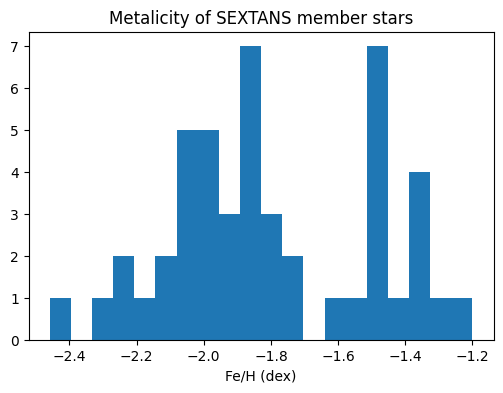

In [29]:
plt.figure(figsize=(6,4)) #Mean metalicity of the member stars.
plt.title("Metalicity of "+ field+" member stars")

plt.hist(apo_vpmg["FE_H"],bins=20);
plt.xlabel("Fe/H (dex)")
print(np.ma.mean(apo_vpmg["FE_H"]))

### Color-Magnitude Diagram

Before running this cell, you need to collect an isochrone grid file from https://stev.oapd.inaf.it/cgi-bin/cmd

I took age and metallicity values from the literature. 

In [30]:
iso_grid = ascii.read("misc/"+field+"_isochrone.dat") #The isochrone grid file
isochrone_ind = np.where((iso_grid["logAge"]==10.0) &(iso_grid["MH"]==-1.6)) #Target galaxy/cluster's parameters

isochrone = iso_grid[isochrone_ind]

mu = 19.8 #Target's distance modulus

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_18843/493601148.py:4: SyntaxWarning: invalid escape sequence '\o'
  cbar = plt.colorbar(cmap="plasma",label="Mass (M$_\odot$)")


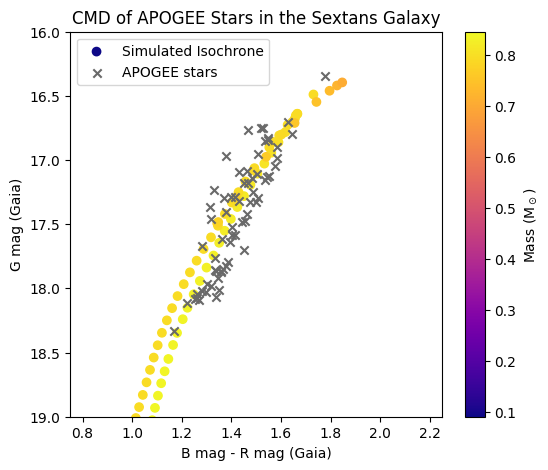

In [31]:
plt.figure(figsize=[6,5])
plt.scatter(isochrone["G_BPmag"]-isochrone["G_RPmag"],isochrone["Gmag"]+mu,c=isochrone["Mass"],
            label = "Simulated Isochrone",cmap ="plasma")
cbar = plt.colorbar(cmap="plasma",label="Mass (M$_\odot$)")
plt.scatter(apo_vpmg["GAIAEDR3_PHOT_BP_MEAN_MAG"]-apo_vpmg["GAIAEDR3_PHOT_RP_MEAN_MAG"],
            apo_vpmg["GAIAEDR3_PHOT_G_MEAN_MAG"],color='dimgray',marker="x", label="APOGEE stars")
plt.clim(min(isochrone["Mass"]), max(isochrone["Mass"]))
plt.xlabel("B mag - R mag (Gaia)")
plt.ylabel("G mag (Gaia)")
plt.title("CMD of APOGEE Stars in the Sextans Galaxy")
plt.legend()

#plt.hlines(18.3, 1,2)
plt.xlim(0.75,2.25)
plt.ylim(16,19)
ax = plt.gca()
ax.invert_yaxis()

plt.savefig(im_folder + "/sextans_CMD.png",dpi=200,bbox_inches='tight')

In [32]:
m_gal = np.mean(isochrone[isochrone["Gmag"] < -1.5]["Mass"]) #Average mass of the stars shown
sd_gal = np.std(isochrone[isochrone["Gmag"] < -1.5]["Mass"])
print(m_gal)
print(sd_gal)

0.7939423076923077
0.026317158384669623


### Log G vs temp

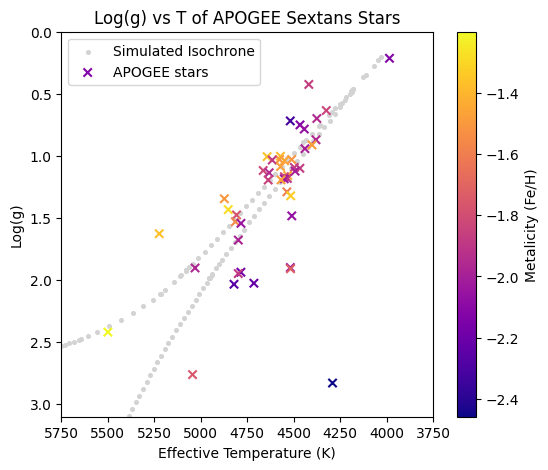

In [33]:
plt.figure(figsize=[6,5])
plt.scatter(10**isochrone["logTe"],isochrone["logg"],c='lightgray', s=7,   #isochrone["Mass"],
            label = "Simulated Isochrone")
plt.scatter(apo_vpmg["TEFF"],apo_vpmg["LOGG"],c=apo_vpmg["FE_H"],marker="x", label="APOGEE stars",cmap ="plasma")
cbar = plt.colorbar(label="Metalicity (Fe/H)")
plt.ylabel("Log(g)")
plt.xlabel("Effective Temperature (K)")
plt.title("Log(g) vs T of APOGEE Sextans Stars")
plt.legend()

#plt.hlines(18.3, 1,2)
#plt.xlim(0.75,2.25)
plt.xlim(3750,5750)
plt.ylim(0,3.1)
ax = plt.gca()
ax.invert_xaxis()
ax.invert_yaxis()

plt.savefig(im_folder + "/sextans_logg_teff.png",dpi=200)

# Part 3: Data Prep & Analysis

## Gaia data

First, let's grab some Gaia things. You'll need to find a sub-file for Gaia for the specific field you're looking at, or otherwise tweak this code depending on your data source.

In [34]:
gaia = Table.read("sextans_gaiadr3.fits")

gaia_inds = np.empty(0)

for ap_id in apo_vpm["GAIAEDR3_SOURCE_ID"]:
    gaia_pos =  int((np.where(gaia["source_id" ]==ap_id)[0][0]))
    gaia_inds = np.append(gaia_inds,gaia_pos)

print(len(gaia_inds))

gaia_sub =gaia[gaia_inds.astype(int)]

70


## V error adjustments

Here, we use RANSAC fitting to derive an adjustment to rv errors. This is based on divergences between v_err and v_scatter which (with the exceptions of binaries and other outliers) should form a 1:1 line. This adjustment was calibrated based on the properties of the Sextans targets, it should work for other dim dwarf-spheroidal galaxies. Nonetheless, double-check thiese plots to make sure they all look reasonable. 

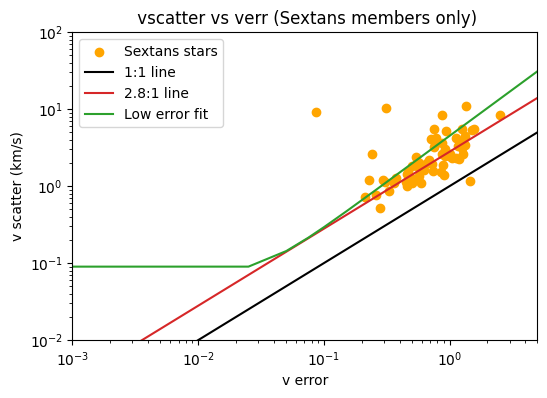

In [35]:
plt.figure(figsize=(6,4))
plt.title(" vscatter vs verr (Sextans members only)")
plt.xlabel("v error")
plt.ylabel("v scatter (km/s)")

plt.scatter(apo_vpmg["VERR"],apo_vpmg["VSCATTER"],color="orange", label="Sextans stars")

x = np.linspace(0,5,num=200)
plt.plot(x,x,color='black', label="1:1 line")

plt.plot(x,x*2.8,color='tab:red', label="2.8:1 line")

fit_line = v_err_adj_1(x)

plt.plot(x,fit_line,color='tab:green',label="Low error fit")

plt.xlim(0.001,5)
plt.ylim(0.01,100)

plt.yscale('log')
plt.xscale('log')
plt.legend()

(array([1074.,  786., 2370., 2124.,  860.,  342.,  111.,  436.,  702.,
         841.,  566.,  373.,  380.,  535.,  422.,  359.,  234.,  175.,
         120.,   76.,   73.,   65.,   27.,   24.,   19.,   29.,   41.,
          41.,   71.,  124.]),
 array([ 3126.01123047,  3683.82202148,  4241.6328125 ,  4799.44335938,
         5357.25439453,  5915.06494141,  6472.87597656,  7030.68652344,
         7588.49707031,  8146.30810547,  8704.11914062,  9261.9296875 ,
         9819.74023438, 10377.55078125, 10935.36230469, 11493.17285156,
        12050.98339844, 12608.79394531, 13166.60449219, 13724.41601562,
        14282.2265625 , 14840.03710938, 15397.84765625, 15955.65820312,
        16513.46875   , 17071.27929688, 17629.09179688, 18186.90234375,
        18744.71289062, 19302.5234375 , 19860.33398438]),
 <BarContainer object of 30 artists>)

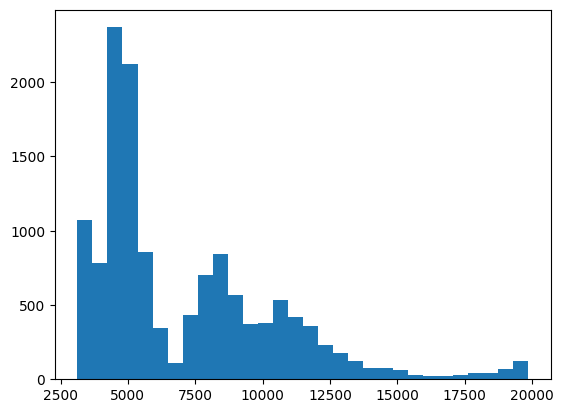

In [36]:
err_stars = all_star[((all_star["VERR"]>0.2)&(all_star["NVISITS"]>5))]
plt.hist(err_stars["TEFF"],bins=30)

In [37]:
err_stars_T = err_stars[(err_stars["TEFF"]<5500)]
err_stars_T = err_stars_T[(err_stars_T["FE_H"]<-1.4)]
print(len(err_stars_T))

1656


In [38]:
fit_params = np.empty((1,2),dtype=float)

X = np.log10(err_stars_T["VERR"].reshape(-1,1))
y = np.log10(err_stars_T["VSCATTER"])

for i in range(1000):
    ransac = linear_model.RANSACRegressor(residual_threshold=0.30)

    ransac.fit(X, y)

    line_X = np.arange(X.min(), X.max())[:, np.newaxis]
    line_y_ransac = ransac.predict(line_X.reshape(-1,1))

    m = ransac.estimator_.coef_[0]
    b = ransac.estimator_.intercept_

    fit_params = np.append(fit_params, [[m,b]],axis=0)
    #binned_dat = np.append(binned_dat, [[bin_t,bin_rv,bin_verr]],axis=0)

fit_params = fit_params[1:]
fit_params = fit_params.T

In [39]:
print(np.std(fit_params[0]))
print(np.median(fit_params[0]))

0.1626786274314874
1.1387796998023987


In [40]:
print(np.std(fit_params[1]))
print(np.median(fit_params[1]))

0.07292593254909858
0.4239646792411804


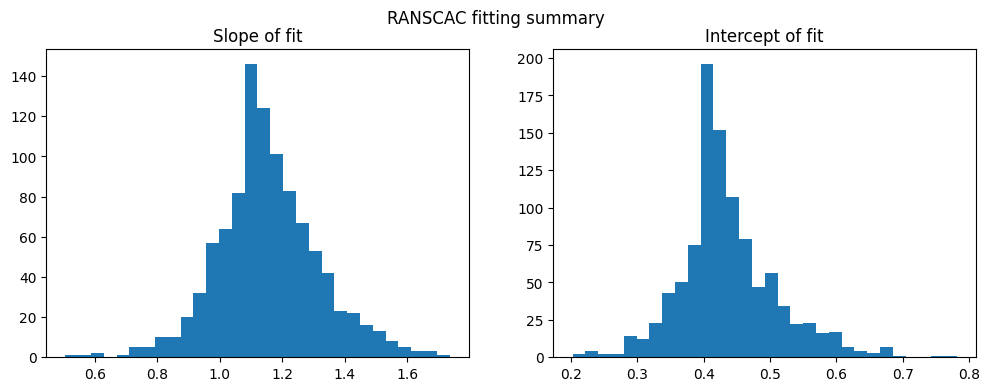

In [41]:
fig, (ax1,ax2) = plt.subplots(1, 2)

fig.set_size_inches([12,4])
fig.suptitle("RANSCAC fitting summary")

ax1.set_title("Slope of fit")
ax1.hist(fit_params[0],bins=30);

ax2.set_title("Intercept of fit")
ax2.hist(fit_params[1],bins=30);

Note that while we *can* pull fit values from the above things, and they will be quite close to the ones we used, I'm coding them in manually here for exactness.

In [42]:
m = 1.13893
b = 0.424407

This cell is just to reproduce an inlier mask for plotting purposes. 

In [43]:
for i in range(1000):
    ransac = linear_model.RANSACRegressor(residual_threshold=0.30)

    ransac.fit(X, y)

    delta_m = np.abs(ransac.estimator_.coef_[0] - m)
    delta_b = np.abs(ransac.estimator_.intercept_ - b)
    j = 0
    if ((delta_m<0.3)&(delta_b<0.15)):
        inlier_mask = ransac.inlier_mask_
        j+=1

print(j)

1


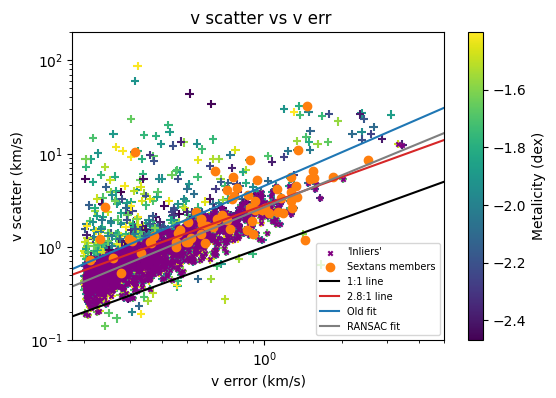

In [44]:
plt.figure(figsize=[6,4]) #plt.figure(figsize=[6,5])
plt.title(" v scatter vs v err")
plt.xlabel("v error (km/s)")
plt.ylabel("v scatter (km/s)")

plt.scatter(err_stars_T["VERR"],err_stars_T["VSCATTER"],marker='+',c=err_stars_T["FE_H"])
plt.colorbar(label="Metalicity (dex)")
plt.scatter(err_stars_T["VERR"][inlier_mask],err_stars_T["VSCATTER"][inlier_mask],marker='x',color="purple",s=10, label="'Inliers'")
#plt.scatter(err_stars_T["VERR"][outlier_mask],err_stars_T["VSCATTER"][outlier_mask],marker='+',,label="Outliers")
plt.scatter(apo_vpm["VERR"],apo_vpm["VSCATTER"], marker = 'o', color="tab:orange",label = 'Sextans members')

x = np.linspace(0.1,5,num=500)
plt.plot(x,x,color='black',label = "1:1 line")

plt.plot(x,x*2.8,color='tab:red',label = "2.8:1 line")

fit_line = v_err_adj_1(x)

plt.plot(x,fit_line,color='tab:blue',label = "Old fit")

adjusted_y = v_err_adj_2(x)

#plt.plot(10**line_X, 10**line_y_ransac, color = 'tab:gray',label = "RANSAC fit")
plt.plot(x, adjusted_y, color = 'tab:gray',label = "RANSAC fit")

plt.xlim(0.18,5)
plt.ylim(0.1,200)

plt.yscale('log')
plt.xscale('log')
plt.legend(prop={'size': 7})

plt.savefig(im_folder + "/scatter_vs_err.png",dpi=200,bbox_inches='tight')

After you've run this fitting a few times, go back up to the v_err_adjust2 function and change it as needed. 

## Fake Star Simulation

Here we simulate fake stars with the same cadence as those observed in our target galaxy. The RVs are randomly generated based on the galactic average values, and the RV errors are taken from the ovservations and assigned at random. 

In [45]:
rng = np.random.default_rng(seed=42)

out_path = "toy_data/"+field+"_sim/"
if not os.path.exists(out_path):
    os.makedirs(out_path)

In [46]:
n = 1
for star in apo_vpm:
    sID = star["APOGEE_ID"]
    visits = all_visits[all_visits["APOGEE_ID"]==sID]

    v_err = v_err_adj_2(visits["VRELERR"])

    toy_data = Table((visits["MJD"],v_err),names = ("MJD", "VRELERR"))
    toy_data.add_column(col = np.zeros(len(toy_data)),name="VHELIO")

    for i in range(8):
        mean_v = rng.normal(rv,rv_scatter)
        carmel = rng.normal(mean_v, visits["VRELERR"])

        toy_data["VHELIO"]=carmel

        write_path = out_path + "sim_"+str(n)+".fits"
        #toy_data.write(write_path,overwrite=True)
        n+=1
    
    #plt.hist(plop)
    #break

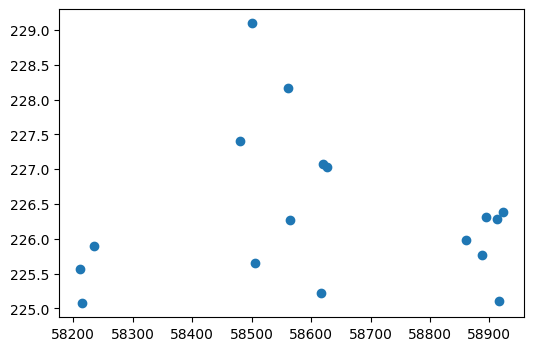

In [47]:
plt.figure(figsize=[6,4]) #Plot one of the toy datas to see if it looks reasonably random. 
plt.scatter(toy_data["MJD"],toy_data["VHELIO"])

### With signal

$$ x = \cos(2 \pi r_1) \cdot 2 \sqrt{r_2(1 - r_2)} $$
$$ y = \sin(2 \pi r_1) \cdot 2 \sqrt{r_2(1 - r_2)} $$
$$ z = 1 - 2 r_2 $$


$$ \phi = 2 \pi \cdot r_1 $$

$$ \cos(\theta) = 1 - 2 r_2 $$

$$ \cos^2(\theta) = 1 - 4 r_2 +4 r_2^2$$

$$ \sin^2(\theta) = 1 - \cos^2(\theta)1 = 4 r_2 -4 r_2^2$$

In [48]:
def rand_phi():
    return 2*np.pi*np.random.rand()

In [49]:
def rand_sini():
    r2 = np.random.rand()
    sini = np.sqrt(1 - r2**2)
    #sign = 2 * np.random.randint(2) - 1 #whether to take the positive or negative square root
    return sini #*sign

In [50]:
rng = np.random.default_rng(seed=42)

out_path = "toy_data/"+field+"_sim_rvs_3/"
if not os.path.exists(out_path):
    os.makedirs(out_path)

In [51]:
n = 1
for star in apo_vpm:
    sID = star["APOGEE_ID"]
    visits = all_visits[all_visits["APOGEE_ID"]==sID]

    v_err = v_err_adj_2(visits["VRELERR"])

    toy_data = Table((visits["MJD"],v_err),names = ("MJD", "VRELERR"))
    toy_data.add_column(col = np.zeros(len(toy_data)),name="VHELIO")

    for i in range(8):
        P = 10**(rng.normal(5.03, 2.28)) * u.day
        m2 = 1.5* m_gal * np.random.rand() * u.solMass
        e = np.random.rand()
        i = np.arcsin(rand_sini()) * u.radian
        omega = 360 *np.random.rand() * u.degree
        M0 = 360 *np.random.rand() * u.degree

        elements = tb.TwoBodyKeplerElements(P=P, m1 = m_gal*u.solMass, m2 = m2, e = e, i = i, omega = omega, M0 = M0 )
        orb1 = tb.KeplerOrbit(elements.get_body(1))
        fake_rvs = orb1.radial_velocity(Time(visits["MJD"],format='mjd'))

        mean_v = rng.normal(rv,rv_scatter)
        carmel = rng.normal(mean_v, visits["VRELERR"]) * (u.km/u.s)

        toy_data["VHELIO"]=fake_rvs + carmel

        orchid = {
            "period": P,
            "m1": m_gal*u.solMass,
            "m2": m2,
            "eccentricity": e,
            "inclination": i,
            "omega": omega,
            "phase": M0
        }
        toy_data.header = orchid

        write_path = out_path + "rv_sim_"+str(n)+".fits"
        toy_data.write(write_path,overwrite=True)
        n+=1

    

**Random distributions:**

m1 = Set fixed (to galaxy value)
m2 = Approximate with a uniform distribution

Periods: Log normal distribution, taken from Raghavan: The dashed curve shows a Gaussian fit to the distribution, with a peak at log P= 5.03 and standard deviation of σlog P = 2.28.
Ecentricity: Uniform? Low eccentricities for <12 days, but that's a small part of our sample. 


M0 = uniform, 0-360


P = Raghavan?

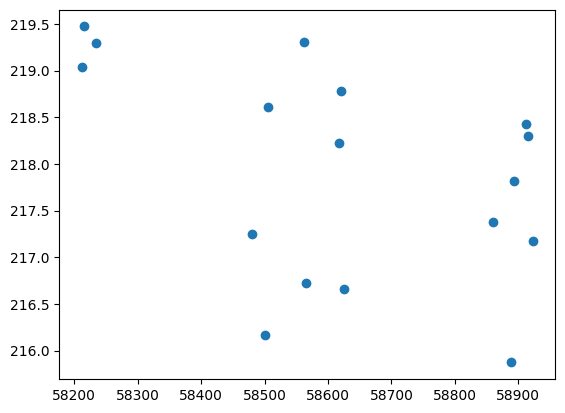

In [52]:
plt.scatter(toy_data["MJD"],fake_rvs+carmel)

# Part 4: Post Joker analysis

Before you can run any of the code after this, you need to run the Joker on the data (both the real and fate stars) and download the resulting samples files. 

## Calculate additional values and store them in the table for ease of use.

In [53]:
g_sol = 27400 *(u.cm/u.s**2) #cm/s^2
nu_sol = 3100e-6 *u.Hz#hz
t_sol = 5777 *u.K
delta_sol = 134.9e-6 *u.Hz

t = apo_vpm["TEFF"] * u.K
g = 10**apo_vpm["LOGG"] *(u.cm/u.s**2)

nu_max = (g/g_sol)/(np.sqrt(t/t_sol))*nu_sol
delta_nu = np.sqrt(np.sqrt((g/g_sol)**3/m_gal)) *delta_sol

apo_vpm.add_column(nu_max,name="NU_MAX")
apo_vpm.add_column(delta_nu,name="DELTA_NU")

In [54]:
surface_orbit = period_at_surface(m_gal, apo_vpm["LOGG"])

apo_vpm.add_column(name="P_SURFACE",col=surface_orbit)
#apo_vpm.replace_column(name="P_SURFACE",col=surface_orbit)

In [55]:
path = "samples/"+field+"/samples_err_fit_5/" #change as necessary
sample_files = glob(path+"*")

In [56]:
col1 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=len(sample_files))
col2 = Table.Column(data=np.full((len(sample_files),256), np.nan), name="JOKER_LN_LIKELIHOOD")
col3 = Table.Column(name="MIN_DELTA_LIKELIHOOD",length=len(sample_files))
col4 = Table.Column(name="MEAN_DELTA_LIKELIHOOD",length=len(sample_files))
col5 = Table.Column(name="MAX_DELTA_LIKELIHOOD",length=len(sample_files))

col6 = Table.Column(name="UNIMODAL_P", length=len(sample_files),dtype=bool)
col7 = Table.Column(name="P_BAR",length=len(sample_files),unit='day')
col8 = Table.Column(name="P_STD",length=len(sample_files),unit='day')
col9 = Table.Column(name="K_BAR",length=len(sample_files),unit='km/s')
col10 = Table.Column(name="K_STD",length=len(sample_files),unit='km/s')
col11 = Table.Column(name="e_BAR",length=len(sample_files))
col12 = Table.Column(name="e_STD",length=len(sample_files))

#col13 = Table.Column(name="FIVE_PERCENTILE",length=len(sample_files))

apo_vpm.add_columns([col1,col2,col3,col4,col5,
                     col6,col7,col8,col9,col10,
                     col11,col12])

In [57]:
for file in sample_files:
    star_path = pathlib.Path(file)
    sID = star_path.parts[-1].split("_")[0]

    data = get_data(sID)
    samples = tj.JokerSamples.read(path+sID+"_samples.hdf5")

    flag_um = tj.is_P_unimodal(samples,data)

    x = (data.t.value)-data.t_ref.value
    y = data.rv.value
    y_err = data.rv_err.value
    X = np.vander(x, N=2, increasing=True)

    Cov = np.diag(y_err**2)
    Cinv = np.linalg.inv(Cov)

    # using the new Python matrix operator
    best_pars_linalg = np.linalg.inv(X.T @ Cinv @ X) @ (X.T @ Cinv @ y)

    # we can also get the parameter covariance matrix
    pars_Cov = np.linalg.inv(X.T @ Cinv @ X)

    cake = ln_likelihood(x,y,y_err,best_pars_linalg)
    sugar = samples.ln_unmarginalized_likelihood(data) #Joker likelihoods
    frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

    min_jkr = np.nanmin(frosting-cake)#[:,None],axis=1)
    mean_jkr = np.nanmean(frosting-cake)#[:,None],axis=1)
    max_jkr = np.nanmax(frosting-cake)#[:,None],axis=1)

    P_bar = np.mean(samples["P"])
    P_std = np.std(samples["P"])

    K_bar = np.mean(samples["K"])
    K_std = np.std(samples["K"])

    e_bar = np.mean(samples["e"])
    e_std = np.std(samples["e"])

    percent = np.percentile(sugar ,5)
    
    #break
    (apo_vpm["LINEAR_LN_LIKELIHOOD"][apo_vpm["APOGEE_ID"]==sID]) = cake
    (apo_vpm["JOKER_LN_LIKELIHOOD"][apo_vpm["APOGEE_ID"]==sID]) = frosting

    (apo_vpm["MIN_DELTA_LIKELIHOOD"][apo_vpm["APOGEE_ID"]==sID]) = min_jkr
    (apo_vpm["MEAN_DELTA_LIKELIHOOD"][apo_vpm["APOGEE_ID"]==sID]) = mean_jkr
    (apo_vpm["MAX_DELTA_LIKELIHOOD"][apo_vpm["APOGEE_ID"]==sID]) = max_jkr
    
    (apo_vpm["UNIMODAL_P"][apo_vpm["APOGEE_ID"]==sID]) = flag_um

    (apo_vpm["P_BAR"][apo_vpm["APOGEE_ID"]==sID]) = P_bar
    (apo_vpm["P_STD"][apo_vpm["APOGEE_ID"]==sID]) = P_std
    (apo_vpm["K_BAR"][apo_vpm["APOGEE_ID"]==sID]) = K_bar
    (apo_vpm["K_STD"][apo_vpm["APOGEE_ID"]==sID]) = K_std
    (apo_vpm["e_BAR"][apo_vpm["APOGEE_ID"]==sID]) = e_bar
    (apo_vpm["e_STD"][apo_vpm["APOGEE_ID"]==sID]) = e_std

## Likelihood Analysis

### Simulated Log-Likelihoods (No signal)

In [58]:
sim_samples = "samples/"+field+"/sim_samples_v5/"
sim_path = "toy_data/"+field+"_sim/sim_"
sim_files = glob(sim_samples+"*")

In [59]:
#calculate log LIKELIHOODs

col1 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=len(sim_files))
col2 = Table.Column(data=np.full((len(sim_files),256), np.nan), name="JOKER_LN_LIKELIHOOD")

sim_LIKELIHOODs = Table((col1,col2))

for file in sim_files:
    samples = tj.JokerSamples.read(file)

    foo_path = pathlib.Path(file)
    fID = foo_path.parts[-1].split(".")[0]
    ID = fID.split("_")[1]

    data_path = sim_path+ID+".fits"
    sim_data = Table.read(data_path)

    sim_data["VHELIO"].unit = u.km/u.s
    sim_data["VRELERR"].unit = u.km/u.s
    
    data = tj.RVData(t=sim_data["MJD"], rv = sim_data["VHELIO"], rv_err = sim_data["VRELERR"])

    sugar = samples.ln_unmarginalized_likelihood(data)
    frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

    x,y,y_err,best_pars_linalg = lin_fit(data)
    
    cake = ln_likelihood(x,y,y_err,best_pars_linalg)

    (sim_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][int(ID)-1]) = cake
    (sim_LIKELIHOODs["JOKER_LN_LIKELIHOOD"][int(ID)-1]) = frosting

INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 3 NaN/Inf data points [thejoker]
INFO: Filtering 15 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 12 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 10 NaN/Inf data points [thejoker]
INFO: Filtering 4 NaN/Inf data points [thejoker]
INFO: Filtering 3 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 11 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 1 NaN/Inf data points [thejoker]
INFO: Filtering 10 NaN/Inf data points [thejoker]
INFO: Filtering 13 NaN/Inf data points [thejoker]
INFO: Filtering 3 NaN/Inf data points [thejoker]
INFO: Filtering 2 NaN/Inf data points [thejoker]
INFO: Filtering 11 NaN/Inf data points [thejoker]
INFO: Filteri

(array([53., 25., 13., 11., 10., 15., 24.,  8., 11., 14.,  2.,  6.,  4.,
         6.,  9.,  5.,  9.,  9., 12., 10.]),
 array([   2.00673562,   53.00234752,  103.99795943,  154.99357134,
         205.98918325,  256.98479516,  307.98040707,  358.97601898,
         409.97163089,  460.9672428 ,  511.96285471,  562.95846662,
         613.95407853,  664.94969044,  715.94530235,  766.94091426,
         817.93652616,  868.93213807,  919.92774998,  970.92336189,
        1021.9189738 ]),
 <BarContainer object of 20 artists>)

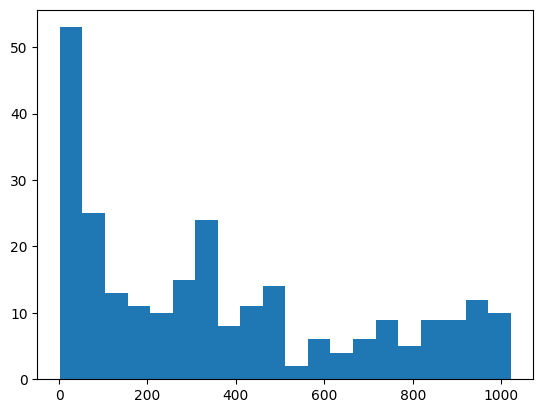

In [61]:
plt.hist(samples["P"],bins=20)

### Simulated Log-Likelihoods (with signal)

In [61]:
sim_samples_2 = "samples/"+field+"/sim_rv_samples_3/"
sim_path_2 = "toy_data/"+field+"_sim_rvs_3/rv_sim_"
sim_files_2 = glob(sim_samples_2+"*")

In [62]:
col3 = Table.Column(name="LINEAR_LN_LIKELIHOOD",length=len(sim_files_2))
col4 = Table.Column(data=np.full((len(sim_files_2),256), np.nan), name="JOKER_LN_LIKELIHOOD")

sim_rv_LIKELIHOODs = Table((col3,col4))

for file in sim_files_2:
    samples = tj.JokerSamples.read(file)

    foo_path = pathlib.Path(file)
    fID = foo_path.parts[-1].split(".")[0]
    ID = fID.split("_")[1]

    print(file)

    data_path = sim_path_2+ID+".fits"
    sim_data = Table.read(data_path)

    print(data_path)

    sim_data["VHELIO"].unit = u.km/u.s
    sim_data["VRELERR"].unit = u.km/u.s
    
    data = tj.RVData(t=sim_data["MJD"], rv = sim_data["VHELIO"], rv_err = sim_data["VRELERR"])

    sugar = samples.ln_unmarginalized_likelihood(data)
    frosting = np.append(sugar,np.full(256-len(sugar), np.nan))

    x,y,y_err,best_pars_linalg = lin_fit(data)
    
    cake = ln_likelihood(x,y,y_err,best_pars_linalg)

    (sim_rv_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][int(ID)-1]) = cake
    (sim_rv_LIKELIHOODs["JOKER_LN_LIKELIHOOD"][int(ID)-1]) = frosting

samples/SEXTANS/sim_rv_samples_3/sim_191_samples.hdf5
toy_data/SEXTANS_sim_rvs_3/rv_sim_191.fits
INFO: Filtering 1 NaN/Inf data points [thejoker]
samples/SEXTANS/sim_rv_samples_3/sim_82_samples.hdf5
toy_data/SEXTANS_sim_rvs_3/rv_sim_82.fits
INFO: Filtering 2 NaN/Inf data points [thejoker]
samples/SEXTANS/sim_rv_samples_3/sim_28_samples.hdf5
toy_data/SEXTANS_sim_rvs_3/rv_sim_28.fits
INFO: Filtering 1 NaN/Inf data points [thejoker]
samples/SEXTANS/sim_rv_samples_3/sim_196_samples.hdf5
toy_data/SEXTANS_sim_rvs_3/rv_sim_196.fits
INFO: Filtering 3 NaN/Inf data points [thejoker]
samples/SEXTANS/sim_rv_samples_3/sim_169_samples.hdf5
toy_data/SEXTANS_sim_rvs_3/rv_sim_169.fits
INFO: Filtering 15 NaN/Inf data points [thejoker]
samples/SEXTANS/sim_rv_samples_3/sim_85_samples.hdf5
toy_data/SEXTANS_sim_rvs_3/rv_sim_85.fits
INFO: Filtering 2 NaN/Inf data points [thejoker]
samples/SEXTANS/sim_rv_samples_3/sim_389_samples.hdf5
toy_data/SEXTANS_sim_rvs_3/rv_sim_389.fits
INFO: Filtering 12 NaN/Inf data 

### False Positive estimation. 

Threshold for selecting "binaries":
- For each simulated system:
    - Compute ∆log-likelihood for all Joker samples (I'll abbreviate that as ∆LL)
    - Compute the mean ∆LL
- Now you have an array of mean ∆LL (one per simulated system)
    - Compute nanpercentile(mean simulated ∆LL, 95) to get a threshold value (or 99, or 90 depending on the contamination rate we want to take on)
- For each APOGEE system:
    - Compute ∆LL for all Joker samples
    - Compute the 5th percentile value
- Now you have an array of 5th percentile ∆LL values (one per APOGEE system)
- Your binary system mask will then be:
    - (5th percentile APOGEE ∆LL) > (threshold)

In [62]:
#Step 1: Array of all mean simulated ∆LL 
sim_delta_ll = sim_LIKELIHOODs["JOKER_LN_LIKELIHOOD"]-sim_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][:,None]
sim_mean_delta_ll = np.nanmean(sim_delta_ll,axis=1)
#Step 2: Compute percentile value
sim_percentile = np.nanpercentile(sim_mean_delta_ll,99)

In [63]:
#Step 3: Calculate ∆LL for all Joker samples
apo_delta_ll = apo_vpm["JOKER_LN_LIKELIHOOD"]-apo_vpm["LINEAR_LN_LIKELIHOOD"][:,None]
apo_percentile = np.nanpercentile(apo_delta_ll,5,axis=1)
threshold = apo_percentile>sim_percentile

In [64]:
print(sum(threshold))
print(np.where(threshold)[0] + 1)

26
[ 1  3  8 10 11 12 14 15 17 20 24 25 27 28 35 38 40 48 52 53 54 61 63 65
 66 68]


In [65]:
can_mask = threshold & (apo_vpm["LOGG"]<3)
apo_can = apo_vpm[can_mask]
apo_vpm.add_column(threshold,name="BINARY_CANDIDATE")

### False Negative Estimation

In [67]:
#Step 3: Calculate ∆LL for all Joker samples
sim_signal_delta_ll = sim_rv_LIKELIHOODs["JOKER_LN_LIKELIHOOD"]-sim_rv_LIKELIHOODs["LINEAR_LN_LIKELIHOOD"][:,None]
sim_signal_percentile = np.nanpercentile(sim_signal_delta_ll,5,axis=1)
recovered = sim_signal_percentile>sim_percentile
print(np.sum(recovered)/len(recovered))

0.0


Plot recovery fraction as a function of estimated period...do this in bins? We need original star periods....shit. Add a header to the fits file with the original period. 

INFO: Filtering 1 NaN/Inf data points [thejoker]


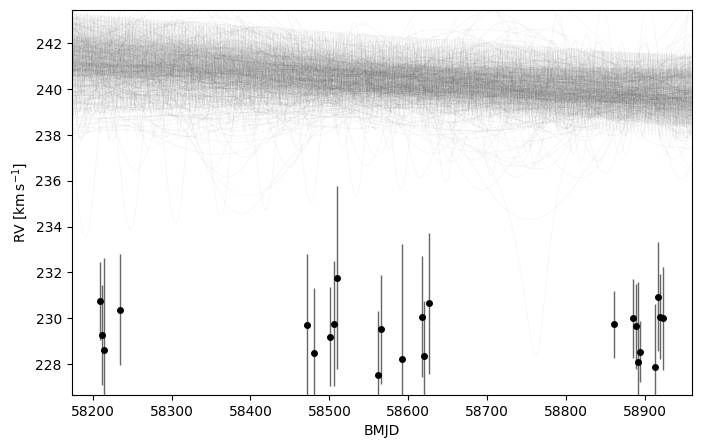

In [68]:
read_path = sim_files_2[110]
samples = tj.JokerSamples.read(read_path)

foo_path = pathlib.Path(sim_files_2[110])
fID = foo_path.parts[-1].split(".")[0]
ID = fID.split("_")[1]

data_path = sim_path_2+ID+".fits"
sim_data = Table.read(data_path)

sim_data["VHELIO"].unit = u.km/u.s
sim_data["VRELERR"].unit = u.km/u.s
    
data1 = tj.RVData(t=sim_data["MJD"], rv = sim_data["VHELIO"], rv_err = sim_data["VRELERR"])
    
plt.figure(figsize=(8,5))
    #_ = tj.plot_rv_curves(top_samples, data=data) #swap out with the one below if you want the top 10 Joker samples
_ = tj.plot_rv_curves(samples, data=data1)

In [69]:
sim_files[117]

'samples/SEXTANS/sim_samples_v5/sim_322_samples.hdf5'

## Calculate companion masses of candidate binaries

In [66]:
mass_col = Table.Column(data=np.full((len(apo_can),256), np.nan),length=len(apo_can))

In [67]:
col = Table.Column(data=np.full((len(apo_can),256), np.nan), name="MSINI")
apo_can.add_column(col)

#(apo_vpm["JOKER_LN_LIKELIHOOD"][apo_vpm["APOGEE_ID"]==sID]) = frosting

In [68]:
im_folder = "images/"+field+"/mass_period/"
if not os.path.exists(im_folder):
    os.makedirs(im_folder)

i = 0

for star in apo_can:
    sID = star['APOGEE_ID']
    read_path = path+sID+"_samples.hdf5"
    im_path = im_folder+sID +"_msini.png"
    samples = tj.JokerSamples.read(read_path)

    msini = mass2(samples["P"],samples["K"],samples["e"],mstar = m_gal)
    frosting = np.append(msini,np.full(256-len(msini), np.nan))
    (apo_can["MSINI"][apo_can["APOGEE_ID"]==sID]) = frosting

    #sugar = samples.ln_unmarginalized_likelihood(data) #Joker likelihoods
    #frosting = np.append(msini,np.full(256-len(msini), np.nan))

    #mass_col[i] = frosting

    #i+=1

    plt.figure(figsize=(8,5))
    plt.title(sID)
    plt.xlabel("Period (days)")
    plt.ylabel("Mass (solar)")

    plt.scatter(samples["P"],msini)
    plt.hlines(0.08, np.min(samples["P"]).value,np.max(samples["P"]).value, color="tab:red")
    
    plt.savefig(im_path,dpi=150)
    plt.close()

## Velocity Dispersion estimation

Hmm. Should we disinclude the stars that ASPCAP failed to fit. Start from there. Maybe do it both ways? Also make sure we don't consider the foreground stars, so use apo_vpmg instead. Also cut out the low-threshold detections. 

In [68]:
samples_mask = (np.sum(~np.isnan(apo_can["JOKER_LN_LIKELIHOOD"]),axis=1)>10) 
apo_can_samples = apo_can[samples_mask]

In [69]:
#not_can = (~threshold)& (apo_vpm["LOGG"]<3) 
not_can = ((~threshold)|(np.sum(~np.isnan(apo_vpm["JOKER_LN_LIKELIHOOD"]),axis=1)<10))& (apo_vpm["LOGG"]<3)
apo_not_can = apo_vpm[not_can.data | not_can.mask]

In [70]:
print("Stars in sample (log g limited): %i" %len(apo_vpmg))
print("Candidate stars (n samples limited): %i" %len(apo_can_samples))
print("Non-candidate stars: %i" %len(apo_not_can))

Stars in sample (log g limited): 66
Candidate stars (n samples limited): 18
Non-candidate stars: 48


In [71]:
binary_fraction = len(apo_can_samples)/len(apo_vpmg)
print(binary_fraction)

0.2727272727272727


(array([26., 24., 13.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.08730303,  0.57395297,  1.0606029 ,  1.54725289,  2.03390288,
         2.52055264,  3.00720263,  3.49385262,  3.98050261,  4.4671526 ,
         4.95380259,  5.44045258,  5.92710209,  6.41375208,  6.90040207,
         7.38705206,  7.87370205,  8.36035156,  8.84700203,  9.33365154,
         9.82030201, 10.30695152, 10.79360199, 11.2802515 , 11.76690197,
        12.25355148]),
 <BarContainer object of 25 artists>)

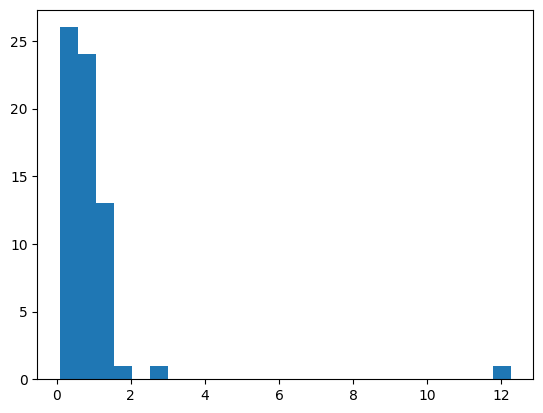

In [72]:
plt.hist(apo_vpmg["VERR"],bins=25)

In [73]:
print(np.std(apo_vpmg["VHELIO_AVG"]))
print(np.std(apo_not_can["VHELIO_AVG"]))
print(np.std(apo_can["VHELIO_AVG"]))

8.675596996464298
9.193215562392812
7.203290565187226


In [74]:
print(mad(apo_vpmg["VHELIO_AVG"]))
print(mad(apo_not_can["VHELIO_AVG"]))
print(mad(apo_can["VHELIO_AVG"]))

8.709484927355103
9.20437943010212
7.9048402174581405


In [75]:
print(np.sqrt(np.mean(apo_vpmg["VHELIO_AVG"]**2)) )
print(np.sqrt(np.mean(apo_not_can["VHELIO_AVG"]**2)) )
print(np.sqrt(np.mean(apo_can["VHELIO_AVG"]**2)) )


224.91724
224.03818
225.83842


In [76]:
print(np.mean(apo_vpmg["VHELIO_AVG"]))
print(np.mean(apo_not_can["VHELIO_AVG"]))
print(np.mean(apo_can["VHELIO_AVG"]))

224.74983723958334
223.8494873046875
225.72349964488637


(array([0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 3., 2., 1., 1., 2., 3.,
        0., 2., 1., 1., 1., 0., 1., 0.]),
 array([202.13746643, 203.65951538, 205.18156433, 206.70361328,
        208.22566223, 209.74771118, 211.26976013, 212.79180908,
        214.31385803, 215.83590698, 217.35795593, 218.88000488,
        220.40205383, 221.92408752, 223.44613647, 224.96818542,
        226.49023438, 228.01228333, 229.53433228, 231.05638123,
        232.57843018, 234.10047913, 235.62252808, 237.14457703,
        238.66662598, 240.18867493]),
 <BarContainer object of 25 artists>)

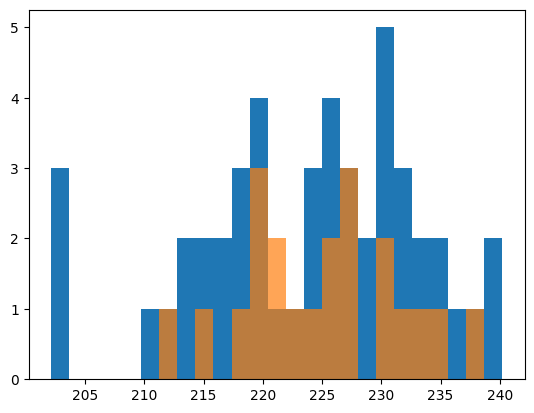

In [77]:
out = plt.hist(apo_not_can["VHELIO_AVG"],bins=25)
plt.hist(apo_can["VHELIO_AVG"],bins=out[1],alpha=0.7)

# Part 5: Post-Joker plots

## Summary Plots (of the entire galaxy)

To make: Eccentricity as a function of P....should this be for every star, or just the binaries? Maybe add the binaries in a different marker? That might be a good idea. See what that looks like. 

### Make E vs P plot for all samples

Look in Adrian's paper for inspiration on styling

Should include all returned samples?

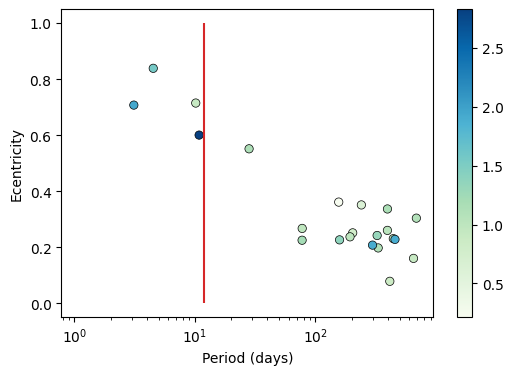

In [79]:
plt.figure(figsize=[6,4])
plt.scatter(apo_can["P_BAR"],apo_can["e_BAR"],c = apo_can["LOGG"],cmap = "GnBu",edgecolors='k',linewidth=0.5)

#plt.yscale('log')
plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Ecentricity")
plt.vlines(12,0,1, color = "tab:red")
plt.colorbar()

Text(0, 0.5, 'Log g')

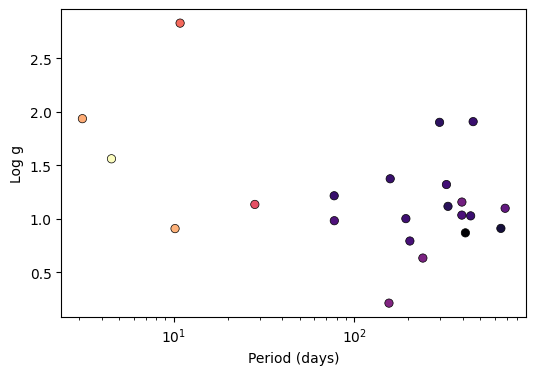

In [103]:
plt.figure(figsize=[6,4])
plt.scatter(apo_can["P_BAR"],apo_can["LOGG"],c = apo_can["e_BAR"],cmap = "magma",edgecolors='k',linewidth=0.5)

#plt.yscale('log')
plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Log g")

### Calculate & plot summary of masses

Ideas: Calculate median masses, standard deviation...how to plot these though? Against median period? Log g?

Text(0, 0.5, 'Avg companion mass (solar)')

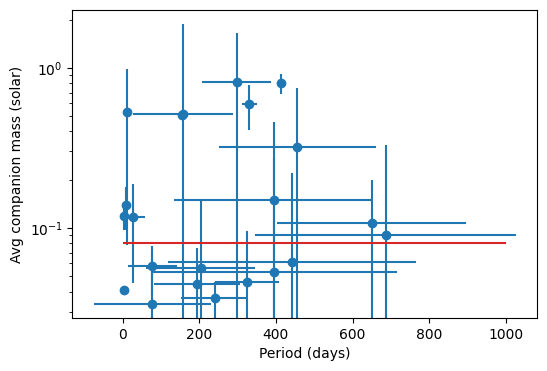

In [87]:
plt.figure(figsize=[6,4])

m_bar = np.empty(0,dtype=float)
m_std = np.empty(0,dtype=float)


for star in apo_can:
    m_avg = np.nanmedian(star["MSINI"])
    m_bar = np.append(m_bar, m_avg)

    m_var = np.nanstd(star["MSINI"])
    m_std = np.append(m_std, m_var)
    
plt.errorbar(apo_can["P_BAR"],m_bar, xerr=apo_can["P_STD"],yerr=m_std,fmt="o")
plt.hlines(0.08, 0,1000, color="tab:red")
plt.yscale('log')
#plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Median companion mass (solar)")

Text(0, 0.5, 'Avg companion mass (solar)')

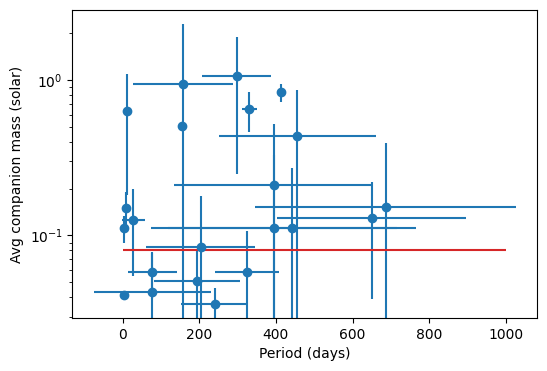

In [90]:
plt.figure(figsize=[6,4])

m_bar = np.empty(0,dtype=float)
m_std = np.empty(0,dtype=float)


for star in apo_can:
    m_avg = np.nanmean(star["MSINI"])
    m_bar = np.append(m_bar, m_avg)

    m_var = np.nanstd(star["MSINI"])
    m_std = np.append(m_std, m_var)
    
plt.errorbar(apo_can["P_BAR"],m_bar, xerr=apo_can["P_STD"],yerr=m_std,fmt="o")
plt.hlines(0.08, 0,1000, color="tab:red")
plt.yscale('log')
#plt.xscale('log')

plt.xlabel("Period (days)")
plt.ylabel("Avg companion mass (solar)")

## Bulk Plots (individual stars)

### RV curves

In [ ]:
out_path = "images/"+field+"/rv_curves_fit/"
if not os.path.exists(out_path):
    os.makedirs(out_path)

In [ ]:
for star in apo_vpm:  #Plot (and save) the Joker-fitted RV curves, with gallactic RV band top 10 samples
    sID = star['APOGEE_ID']
    visits = all_visits[all_visits['APOGEE_ID']==sID]
    
    data = get_data(sID)
    data.rv_err = v_err_adj_2(data.rv_err)
    
    read_path = path+sID+"_samples.hdf5"
    im_path = out_path+sID +"_rv_curve.png"
    
    samples = tj.JokerSamples.read(read_path)

    sorted_lk = np.argsort(samples['ln_likelihood'])[::-1]
    top_samples = samples[sorted_lk[0:10]]
    
    plt.figure(figsize=(8,5))
    #_ = tj.plot_rv_curves(top_samples, data=data) #swap out with the one below if you want the top 10 Joker samples
    _ = tj.plot_rv_curves(samples, data=data)
    #plt.title(sID)
    
    ax = plt.gca()
    ax.axhline(rv,color="tab:blue",lw=1)
    ax.axhspan(rv-rv_scatter, rv + rv_scatter, facecolor="tab:blue", alpha=0.7)

    plt.scatter(data.t.mjd,data.rv,color='black');
    plt.errorbar(data.t.mjd,data.rv,yerr=data.rv_err,fmt="o",color='black');

    #good_visits = visits[visits['STARFLAG']==0] #This stuff colors good/bad visits differently
    #bad_visits = visits[visits['STARFLAG']>0]

    #plt.scatter(good_visits['JD'],good_visits['VHELIO'],color='black');
    #plt.errorbar(good_visits['JD'],good_visits['VHELIO'],yerr=good_visits['VRELERR'],fmt="o",color='black');

    #plt.scatter(bad_visits['JD'],bad_visits['VHELIO'],color='gray');
    #plt.errorbar(bad_visits['JD'],bad_visits['VHELIO'],yerr=bad_visits['VRELERR'],fmt="o",color='gray');
        
    plt.savefig(im_path,dpi=150)
    plt.close()

### Period vs Ecentricity (& period histogram)

In [ ]:
out_path = "images/"+field+"/p_vs_e/"
if not os.path.exists(out_path):
    os.makedirs(out_path)

out_path2 = "images/"+field+"/p_hist/"
if not os.path.exists(out_path2):
    os.makedirs(out_path2)

In [ ]:
for star in apo_vpm:  
    sID = star['APOGEE_ID']
    data = get_data(sID)
    n_data = len(data)

    nu_max = star["NU_MAX"] *u.Hz
    P = (1/nu_max).to(u.day).value
    T = star["P_SURFACE"]
    ###
    
    read_path = path+sID+"_samples.hdf5"
    hist_path = out_path+sID+"_histogram.png"
    Pe_path = out_path2+sID+"_pe_scatter.png"
    
    samples = tj.JokerSamples.read(read_path)
    n_samples = len(samples)
    
    textstr = '\n'.join((
        r'Visits: %d' % (n_data, ),
        r'Samples: %d' % (n_samples, )))
    
    plt.figure(figsize=(8,5))
    plt.hist(samples["P"],bins=20,color="black")
    
    plt.xlabel("Period (days)")
    plt.ylabel("# of returned samples")
    plt.title("Period Histogram of Joker Samples")
    
    ax = plt.gca()
    leg = ax.legend(labels=[textstr],handlelength=0, handletextpad=0, fancybox=True)
    for item in leg.legend_handles:
            item.set_visible(False)
    
    plt.savefig(hist_path,dpi=200)
    plt.close()
    ###
    
    plt.figure(figsize=(8,5))
    plt.scatter(samples["P"],samples["e"], color="black")
    plt.vlines(T,0,1,colors='tab:red',label="Stellar Surface")
    plt.vlines(P,0,1,colors='tab:green',label="Max Oscillation Mode")
    
    plt.xlabel("Period (days)")
    plt.ylabel("Eccentricity")
    plt.title("Eccentricity vs Period")
    
    ax = plt.gca()
    leg = ax.legend(labels=[textstr],handlelength=0, handletextpad=0, fancybox=True,loc='upper left')
    for item in leg.legend_handles:
            item.set_visible(False)

    plt.legend()
    ax.add_artist(leg)
    
    plt.savefig(Pe_path,dpi=200)
    plt.close()

### Log Probatility histograms

In [ ]:
out_path = "images/"+field+"/likelihood_hist/"
if not os.path.exists(out_path):
    os.makedirs(out_path)

In [ ]:
for star in apo_vpm:
    sID = star["APOGEE_ID"]
    plt.figure(figsize=(8,5))
    im_path = out_path+sID +"_likelihoods.png"
    
    linear_lk = star["LINEAR_LN_LIKELIHOOD"]
    joker_lk = star["JOKER_LN_LIKELIHOOD"]

    plt.title("Log Likelihoods (Unadjusted error)")
    out = plt.hist(joker_lk,bins=25,color='tab:blue',label="Joker ln likelihoods")
    plt.vlines(linear_lk,0,np.max(out[0]),color='tab:red',label="Linear ln likelihood")

    plt.legend()
    plt.savefig(im_path,dpi=150)
    plt.close()

### Phase-Folded plots (takes a long time to run)

In [ ]:
for star in apo_vpm:  #Plot (and save) the Joker-fitted RV curves, phase-folded
    sID = star['APOGEE_ID']
    
    data = get_data(sID)
    
    read_path = path+sID+"_samples.hdf5"
    im_folder = "images/"+field+"/phase_folded/"+sID #+"_models.pdf"
    
    if not os.path.exists(im_folder):
        os.makedirs(im_folder)
    
    samples = tj.JokerSamples.read(read_path)

    vex = Table([samples.ln_unmarginalized_likelihood(data)], names=['likelihood'])
    vex = vex.group_by("likelihood")
    vex.add_column(np.flip(np.arange(len(samples))),name='index')
    
    for j in range(len(samples)):
        sample = samples[j]

        lnlk = sample.ln_unmarginalized_likelihood(data)[0]
        k = vex[vex['likelihood']==lnlk]['index']
        
        #plt.figure(figsize=(8,5))
        _ = tj.plot_phase_fold(sample, data=data)
        plt.title(sID+ " (phase folded)")
    
        P = sample['P'].value[0]
        e = sample['e'].value[0]
        K = sample['K'].value[0]
        v0 = sample['v0'].value[0]
        
        #print(e)
        
        textstr = '\n'.join((
            r'$P=%.2f$ days' % (P, ),
            r'$e=%.3f$' % (e, ),
            r'$K=%.3f$' % (K, ),
            r'$v_0=%.3f$' % (v0, )))
        
        ax = plt.gca()
        leg = ax.legend(labels=[textstr],handlelength=0, handletextpad=0, fancybox=True)
        for item in leg.legend_handles:
            item.set_visible(False)
        
        index = str(k.value[0])
        im_path =  im_folder +"/" + "Phase_" +index+ ".png"
        #print(im_path)
        
        plt.savefig(im_path,dpi=200)
        del(ax)
        plt.close()
    
    

# Website building things

Too much to write by hand, lots of stars. 

## Individual Star Pages

### Sub-functions for berevity

In [ ]:
path = 

In [83]:
def mk_header(field_name, star):
    with open("web_templates/star_header.txt","r") as f:
        head_tmp = f.read()
        
    sID = star['APOGEE_ID']

    head_str = head_tmp % field_name
    return head_str

In [84]:
def mk_info(field_name, star): #Makes a summary info list
    with open("web_templates/info_box.txt","r") as f:
        info_tmp = f.read()
    
    sID = star['APOGEE_ID']
    k = np.where(apo_vpm["APOGEE_ID"]==sID)[0][0]+1
    gaia_dat = gaia_sub[gaia_sub["source_id"]==star["GAIAEDR3_SOURCE_ID"]]

    data = get_data(sID)
    read_path = path+sID+"_samples.hdf5"
    samples = tj.JokerSamples.read(read_path)

    n_visits = len(data)
    snr = star["SNR"]
    h = star["H"]
    g_m = star["GAIAEDR3_PHOT_G_MEAN_MAG"]

    ruwe = gaia_dat["ruwe"]
    gaia_n = gaia_dat["astrometric_excess_noise"]
    gaia_n_sig = gaia_dat["astrometric_excess_noise_sig"]
    gof = gaia_dat["astrometric_gof_al"]

    t = star["TEFF"]
    g = star["LOGG"]
    fe = star["M_H"]

    rv_t = star["RV_TEFF"]
    rv_g = star["RV_LOGG"]
    rv_fe = star["RV_FEH"]

    n_samples = len(samples)
    unimodal = tj.is_P_unimodal(samples,data)
    P_avg = np.mean(samples["P"]).value
    e_avg = np.mean(samples["e"]).value
    K_avg = np.mean(np.abs(samples["K"])).value
    min_del_lk = min(star["JOKER_LN_LIKELIHOOD"]-star["LINEAR_LN_LIKELIHOOD"])

    nu_max = star["NU_MAX"]
    delta_nu = star["DELTA_NU"]
    p_surface = star["P_SURFACE"]

    params = (k, sID,
              field_name, sID, sID,
              n_visits, snr, h, g_m,
              ruwe, gaia_n, gaia_n_sig, gof,
              t, g, fe,
              rv_t, rv_g, rv_fe,
              n_samples, unimodal, P_avg, e_avg, K_avg, min_del_lk,
              nu_max, delta_nu, p_surface)

    info_str = info_tmp %params
    return info_str

In [85]:
def mk_binary_info(field_name, star):
    with open("web_templates/binary_info.txt","r") as f:
        binary_tmp = f.read()

    sID = star['APOGEE_ID']
    params = (sID, sID)

    binary_str = binary_tmp %params
    return binary_str

In [86]:
def mk_gallery(field_name, star):
    with open("web_templates/star_gallery.txt","r") as f:
        gallery_tmp = f.read()

    sID = star['APOGEE_ID']
    sreps = np.repeat(sID, 16)

    gallery_str = gallery_tmp % tuple(sreps) #Change the number of repeats if you change the page layout
    return gallery_str

In [87]:
def mk_visit_table(field_name, star):
    with open("web_templates/star_table_head.txt","r") as f:
        head_tmp = f.read()
    with open("web_templates/star_table_row.txt","r") as f:
        row_tmp = f.read()
    foot_str = '\n\t\t</table>\n'

    sID = star['APOGEE_ID']
    visits = all_visits[all_visits['APOGEE_ID']==sID]
    visits.sort("MJD")

    body_str = ''

    for visit in visits:

        if(visit["SNR"]<5):
            params = (visit["MJD"], "<b>"+str(visit["SNR"])+"</b>", visit["VHELIO"],visit["VRELERR"], 
                    visit["RV_TEFF"], visit["RV_LOGG"], visit["RV_FEH"],
                    visit["STARFLAGS"], visit["RV_FLAG"])
        else:
            params = (visit["MJD"], visit["SNR"], visit["VHELIO"],visit["VRELERR"], 
                       visit["RV_TEFF"], visit["RV_LOGG"], visit["RV_FEH"],
                       visit["STARFLAGS"], visit["RV_FLAG"])

        row_str = row_tmp % params
        body_str = body_str + row_str

    table_str = head_tmp + body_str + foot_str

    return table_str
#don't forget to add closing table tag

In [88]:
def mk_phase_gal(field_name, star):
    sID = star['APOGEE_ID']
    data = get_data(sID)
    read_path = path+sID+"_samples.hdf5"
    samples = tj.JokerSamples.read(read_path)
    
    phase_str = "\n<br>\n<hr>\n"
    
    for i in range(len(samples)):
        ind = str(i)
        phase_str = str(phase_str+'\t\t<img src="/images/sextans/phase_folded/'+
                        sID+'/Phase_'+ind+'.png" alt="Phase 0" id="three_image">\n')

    return phase_str

In [89]:
def mk_footer(field_name = "foo",star = "foo"):
    with open("web_templates/footer.txt","r") as f:
        foot_tmp = f.read()

    return foot_tmp

### Actual function calls

In [90]:
for star in apo_vpm:
    sID = star['APOGEE_ID']
    
    head_str = mk_header(field.lower(), star)
    info_str = mk_info(field.lower(), star)
    table_str = mk_visit_table(field.lower(), star)
    gallery_str = mk_gallery(field.lower(), star)
    phase_str = mk_phase_gal(field.lower(), star)
    foot_str = mk_footer()

    if(star["BINARY_CANDIDATE"]):
        binary_str = mk_binary_info(field.lower(), star)
    else:
        binary_str = ""

    out_path = "html/"+field+"/%s.html" %sID
    out = open(out_path, 'w')

    text = str(head_str+ info_str+ binary_str+ table_str+ gallery_str+ phase_str+ foot_str) #Add in stuff for phase folding
    
    out.write(text)

/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/3076544127.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  info_str = info_tmp %params
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/2109466406.py:25: UserWarning: Warning: converting a masked element to nan.
  row_str = row_tmp % params
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/3076544127.py:51: UserWarning: Warning: converting a masked element to nan.
  info_str = info_tmp %params


## Summary Table for a galaxy

re-write this part to open the html file, and append stuff to it?

In [91]:
def mk_gal_row(field_name, star):
    with open("web_templates/gal_table_row.txt","r") as f:
        row_tmp = f.read()

    sID = star['APOGEE_ID']
    k = np.where(apo_vpm["APOGEE_ID"]==sID)[0][0]+1
    data = get_data(sID)
    read_path = path+sID+"_samples.hdf5"
    samples = tj.JokerSamples.read(read_path)

    if(star["BINARY_CANDIDATE"]):
        tag = " id='binary'"
    else:
        tag = ""

    foo = sID.split("-")
    sID_split = foo[0]+"<br>-"+foo[1]

    t = star["TEFF"]
    g = star["LOGG"]
    fe = star["M_H"]
    h = star["H"]
    g_m = star["GAIAEDR3_PHOT_G_MEAN_MAG"]

    n_samples = len(samples)
    unimodal = tj.is_P_unimodal(samples,data)
    P_avg = np.mean(samples["P"]).value
    e_avg = np.mean(samples["e"]).value

    gaia_dat = gaia_sub[gaia_sub["source_id"]==star["GAIAEDR3_SOURCE_ID"]]
    gaia_n = gaia_dat["astrometric_excess_noise"]

    params = (tag, k,
              field_name, sID, sID_split,
              t, g, fe, h, g_m,
              field_name, sID, field_name, sID, sID,
              n_samples, unimodal, P_avg, e_avg, gaia_n,
              field_name, sID, field_name, sID, sID)

    row_str = row_tmp % params
    return row_str

In [93]:
page_path = "html/galaxy/%s.html" %field.lower()

with open(page_path) as f:
    lines = f.readlines()

out = open(page_path, 'w')

lines = np.array(lines,dtype='U1000')

start = np.where(lines=="<!--start-->\n")[0][0]+1
stop = np.where(lines=="<!--stop-->\n")[0][0]

lines = np.delete(lines, range(start,stop))

table_str = np.empty(0,dtype='U1000')

for star in apo_vpm:
    row_str = mk_gal_row(field.lower(), star)
    table_str = np.append(table_str,row_str)


out_page = np.insert(lines, start, table_str)
out.writelines(out_page)

/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/1801801796.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  row_str = row_tmp % params
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_99887/1801801796.py:40: UserWarning: Warning: converting a masked element to nan.
  row_str = row_tmp % params


In [82]:
np.array2string(out_page)

'[\'<!DOCTYPE HTML>\\n\' \'<html>\\n\' \'\\n\' \'<head>\\n\'\n \'  <meta charset="UTF-8">\\n\'\n \'  <title>Quentin Lucas - Sextans Galaxy</title>\\n\'\n \'  <link rel="stylesheet" href="/css/research.css"  type="text/css">\\n\'\n \'  <link rel="stylesheet" href="/css/global.css" type="text/css">\\n\'\n \'  <link href="https://fonts.googleapis.com/css?family=Slabo+27px" rel="stylesheet">\\n\'\n \'</head>\\n\' \'\\n\' \'<body>\\n\' \'\\n\' \'\\t<div id="header">\\n\' \'\\t\\n\' \'\\n\'\n \'\\t\\t<img width="300" style="margin:0px auto;display:inline" src="/images/logo.png" alt="Quentin Lucas, Astrophysics" title="Art by Siena Buchanan"/>\\n\'\n \'\\n\' \'\\n\' \'\\t<div id="info_box">\\n\' \'\\t\\n\' \'\\t\\tDepartment of Physics\\n\'\n \'\\t\\t<br>\\n\' \'\\t\\tMontana State University\\n\' \'\\t\\t<br>\\n\'\n \'\\t\\tquentinlucas@msu.montana.edu\\n\' \'\\t\\n\' \'\\t</div>\\n\' \'\\t\\n\'\n \'\\t<ul id="nav_bar">\\n\' \'\\t\\n\'\n \'\\t\\t<li id="left_button"><a href="/index.html" cla

In [70]:
mk_gal_row(field.lower(), star)

/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_45357/2538033977.py:37: UserWarning: Warning: converting a masked element to nan.
  row_str = row_tmp % params
/var/folders/b5/gm7vz31d7cz5k6m1r9bknccr0000gp/T/ipykernel_45357/2538033977.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  row_str = row_tmp % params


'\t\t<tr>\n\t\t\t<td>70</td>\n\t\t\t<td><a href="/html/sextans/2M10131874-0131139">2M10131874<br>-0131139</a></td>\n\t\t\t<td>T_eff = nan<br>\n\t\t\t\tlog(g) = nan<br>\n\t\t\t\tmetalicity = nan<br>\n\t\t\t\th mag = 15.350<br>\n\t\t\t\tgaia g mag = 17.823<br></td>\n\t\t\t<td><a href="/images/sextans/rv_curves_fit/2M10131874-0131139_rv_curve.png" target="_blank"><img src="/images/sextans/rv_curves_fit/2M10131874-0131139_rv_curve.png" alt="2M10131874-0131139" id="table_image"></a></td>\n\t\t\t<td>N = 13<br>\n\t\t\t\tUnimodal? True<br>\n\t\t\t\tavg P = 317.80<br>\n\t\t\t\tavg e = 0.46<br>\n\t\t\t\tGAIA Noise = 0.00<br></td>\n\t\t\t<td><a href="/images/sextans/likelihood_hist/2M10131874-0131139_likelihoods.png" target="_blank"><img src="/images/sextans/likelihood_hist/2M10131874-0131139_likelihoods.png" alt="2M10131874-0131139" id="table_image"></a></td>\n\t\t</tr>'

TypeError: order must be str, not int

In [90]:
table_str = ""

for star in apo_vpm:
    row_str = mk_gal_row(field.lower(), star)
    table_str = table_str + row_str



array(['<!DOCTYPE HTML>\n', '<html>\n', '\n', ..., '</body>\n', '\n',
       '</html>\n'], dtype='<U247')

In [96]:
with np.printoptions(threshold=np.inf):
    print(np.insert(lines, 3, ["Bono is cool"]))

['<!DOCTYPE HTML>\n' '<html>\n' '\n' '<head>\n'
 '  <meta charset="UTF-8">\n'
 '  <title>Quentin Lucas - Sextans Galaxy</title>\n'
 '  <link rel="stylesheet" href="/css/research.css"  type="text/css">\n'
 '  <link rel="stylesheet" href="/css/global.css" type="text/css">\n'
 '  <link href="https://fonts.googleapis.com/css?family=Slabo+27px" rel="stylesheet">\n'
 '</head>\n' '\n' '<body>\n' '\n' '\t<div id="header">\n' '\t\n' '\n'
 '\t\t<img width="300" style="margin:0px auto;display:inline" src="/images/logo.png" alt="Quentin Lucas, Astrophysics" title="Art by Siena Buchanan"/>\n'
 '\n' '\n' '\t<div id="info_box">\n' '\t\n' '\t\tDepartment of Physics\n'
 '\t\t<br>\n' '\t\tMontana State University\n' '\t\t<br>\n'
 '\t\tquentinlucas@msu.montana.edu\n' '\t\n' '\t</div>\n' '\t\n'
 '\t<ul id="nav_bar">\n' '\t\n'
 '\t\t<li id="left_button"><a href="/index.html" class="nav">Home</a></li>\n'
 '\t\t<li><a href="/html/research.html" class="nav">Research</a></li>\n'
 '\t\t<li><a href="/html/vitae.

In [106]:
np.where(lines=="<!--start-->\n")[0][0]

62

In [ ]:
file = "plots/sextans/table_html.txt"
out = open(file, 'w')

i = 0
for star in apo_vpm: 
    i+=1
    sID = star['APOGEE_ID']
    
    t = star["TEFF"]
    g = star["LOGG"]
    m = star["M_H"]
    h = star["H"]
    g_m = star["GAIAEDR3_PHOT_G_MEAN_MAG"]
    
    params = '\n\t\t\t\t'.join((
        'T_eff = %.3f<br>' % (t, ),
        'log(g) = %.3f<br>' % (g, ),
        'metalicity = %.3f<br>' % (m, ),
        'h mag = %.3f<br>' % (h, ),
        'gaia g mag = %.3f<br>' % (g_m, )))
    
    im_path = "/images/sextans/curves_med_err/"+sID +"_rv_curve.png"
    ccf_path = "/images/sextans/ccfs2/asStar-dr17-"+sID +"_ccf.png"
    hist_path = "/images/sextans/likelihood_hist_med_err/"+sID +"_likelihoods.png"
    
    ################
    
    data = get_data(sID)
    
    read_path = "plots/sextans/samples/joker_samples_med/"+sID+"_samples.hdf5"
    samples = tj.JokerSamples.read(read_path)
    
    n_fits = len(samples)
    flag_um = tj.is_P_unimodal(samples,data)
    #flag_km, modes, distribution = tj.is_P_Kmodal(samples,data)
    LIKELIHOOD = star["MEAN_DELTA_LIKELIHOOD"]#min(star["JOKER_LN_LIKELIHOOD"]-star["LINEAR_LN_LIKELIHOOD"]) 

    #############
    gaia_dat = gaia_sub[gaia_sub["source_id"]==star["GAIAEDR3_SOURCE_ID"]]
    g_noise = gaia_dat["astrometric_excess_noise"][0]

    #############
    
    #if(flag_um):
    P_bar = np.mean(abs(samples['P']))
    e_bar = np.mean(samples['e'])
        
    fit_str = '\n\t\t\t\t'.join((
            'N = %d<br>' % (n_fits, ),
            'Unimodal? %s' % (flag_um),
            'avg P = %.2f<br>' % (P_bar.value, ),
            'avg e = %.2f<br>' % (e_bar.value, ),
            #'min Δ LIKELIHOOD = %.2f<br>' %LIKELIHOOD),
            'Gaia Noise = %.4f<br>' % (g_noise, )))
    #elif(flag_km):
        #n_modes = len(modes)
        
        #fit_str = '\n\t\t\t\t'.join((
            #'$N=%d<br>' % (n_fits, ),
            #'P: K-modal<br>',
            #'$\n (modes)=%d<br>' % (n_modes, )))
    #else:
    #    fit_str = '\n\t\t\t\t'.join((
    #        'N=%d<br>' % (n_fits, ),
    #        'unimodal P? %s<br>' % ("No", ),
    #        'min Δ LIKELIHOOD = %.2f<br>' %LIKELIHOOD))
        
    ################
        #<td><a href="/html/sextans/2M10094908-0126325.html">2M10094908-0126325</a></td>

    foo = sID.split("-")
    foof = foo[0]+"<br>-"+foo[1]

    ##
    if(star["BINARY_CANDIDATE"]):
        l_start = '\t\t<tr id="binary">\n'
    else:
        l_start = '\t\t<tr>\n'
    ##

    #l_start = '\t\t<tr>\n'
    l0 = '\t\t\t<td>%d</td>\n'%i
    l1 = '\t\t\t<td><a href="/html/sextans/'+sID+'.html">'+foof+'</a></td>\n'
    l2 = '\t\t\t<td>'+params+'</td>\n'
    l3 = '\t\t\t<td><a href="'+im_path+' "target="_blank"><img src=\"'+im_path+'\" alt=\"'+sID+'\" id=\"table_image\"></a></td>\n'
    l4 = '\t\t\t<td>'+fit_str+'</td>\n'
    l5 = '\t\t\t<td><a href="'+hist_path+' "target="_blank"><img src=\"'+hist_path+'\" alt=\"'+sID+' ccf\" id=\"table_image\"></td>\n'
    l_end = '\t\t</tr>\n'

    text = str(l_start+l0+l1+l2+l3+l4+l5+l_end)

    print(i)
    out.write(text)
    
    #break